Importing Important Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

Importing the dataset as Pandas DataFrame

In [2]:
df= pd.read_csv(r"C:\Users\pulki\News Topic Classification\data\train.csv")
df= df.sample(20000)

In [3]:
import re

def clean_text(text):
    text= text.lower()
    text= re.sub(r'^[a-zA-Z]', '', text)
    text= re.sub(r'\s+', ' ', text)
    return text

Combining the Title and Description of the dataset

In [4]:
df['text']= (df['Title'] + " " + df['Description']).apply(clean_text)

Encoding Labels 

In [5]:
df['label']= df['Class Index'] - 1
df['label']

114239    3
83052     3
34120     0
64050     0
25515     2
         ..
119883    1
104501    2
9683      0
96832     2
6251      1
Name: label, Length: 20000, dtype: int64

In [6]:
X= df['text']
y= df['label']

Train-Test-Split of the dataset 

In [7]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.3, random_state= 12)

Applying Tokenization

In [ ]:
max_words= 20000

tokenizer= Tokenizer(num_words= max_words, oov_token= "<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq= tokenizer.texts_to_sequences(X_train)
X_test_seq= tokenizer.texts_to_sequences(X_test)

Applying padding

In [9]:
max_len= 200

X_train_pad= pad_sequences(X_train_seq, maxlen= max_len, padding= 'post')
X_test_pad= pad_sequences(X_test_seq, maxlen= max_len, padding= 'post')

Applying LSTM and Embedding

In [ ]:
from tensorflow.keras.layers import Bidirectional

model= Sequential()

model.add(Embedding(input_dim= max_words, output_dim= 128, input_length= max_len))

model.add(Bidirectional(LSTM(64, return_sequences= True)))
model.add(Dropout(0.2))

model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.2))

model.add(Dense(64, activation= 'relu'))
model.add(Dense(4, activation= 'softmax'))

C:\Users\pulki\miniconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [11]:
model.compile(
    optimizer= "Adam",
    loss= "sparse_categorical_crossentropy",
    metrics= ["accuracy"]
)

In [12]:
history= model.fit(
    X_train_pad,
    y_train,
    validation_split= 0.2,
    epochs= 10,
    batch_size= 64
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.6907 - loss: 0.7297 - val_accuracy: 0.8664 - val_loss: 0.4013
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.9271 - loss: 0.2317 - val_accuracy: 0.8736 - val_loss: 0.3977
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.9740 - loss: 0.0896 - val_accuracy: 0.8546 - val_loss: 0.5093
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.9878 - loss: 0.0467 - val_accuracy: 0.8546 - val_loss: 0.5936
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.9911 - loss: 0.0340 - val_accuracy: 0.8629 - val_loss: 0.5929
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 188s 738ms/step - accuracy: 0.9935 - loss: 0.0224 - val_accuracy: 0.8618 - val_loss: 0.6512
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 145s 826ms/step - accuracy: 0.9946 - loss: 0.0188 - val_accuracy: 0.8579 - val_loss: 0.7018
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.9954 - loss: 0.0167 - va

In [13]:
test_loss, test_acc= model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", test_acc)

188/188 ━━━━━━━━━━━━━━━━━━━━ 36s 192ms/step - accuracy: 0.8535 - loss: 0.7541
Test Accuracy: 0.8535000085830688


In [14]:
sample= ["Apple releases new AI powered IPhone"]

seq= tokenizer.texts_to_sequences(sample)
pad= pad_sequences(seq, maxlen= max_len)

prediction= model.predict(pad)
print(np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
3


In [15]:
model.save("news_classifier.h5")

Plotting Graphs

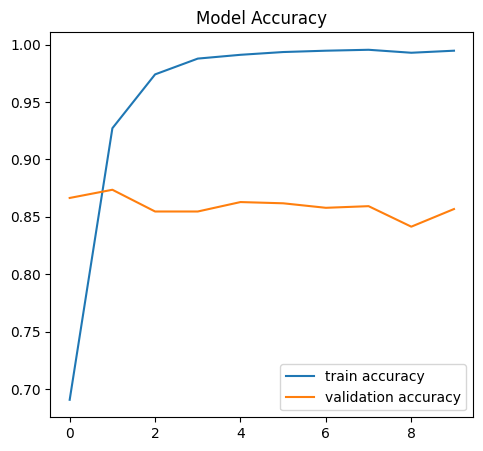

In [16]:
plt.figure(figsize= (12,5))

#Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label= 'train accuracy')
plt.plot(history.history['val_accuracy'], label= 'validation accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

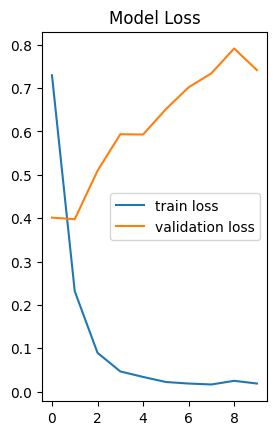

In [17]:
#Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label= 'train loss')
plt.plot(history.history['val_loss'], label= 'validation loss')
plt.legend()
plt.title("Model Loss")
plt.show()

188/188 ━━━━━━━━━━━━━━━━━━━━ 37s 184ms/step


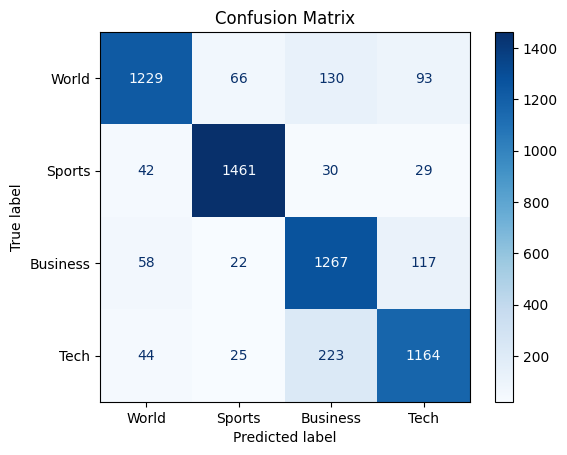

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred= model.predict(X_test_pad)
y_pred_classes= np.argmax(y_pred, axis=1)

cm= confusion_matrix(y_test, y_pred_classes)

disp= ConfusionMatrixDisplay(confusion_matrix= cm, display_labels= ["World", "Sports", "Business", "Tech"])

disp.plot(cmap= "Blues")
plt.title("Confusion Matrix")
plt.show()

In [21]:
import pickle 

pickle.dump(tokenizer, open("tokenizer.pkl", "wb"))

## Conclusion

In this project, we built an end-to-end **News Topic Classification system** using Natural Language Processing and Deep Learning.

The goal was to automatically classify news headlines into four categories: **World, Sports, Business, and Sci/Tech**.

### Key Steps in the Project

1. **Data Preprocessing**
   - Cleaned and prepared the text dataset
   - Tokenized headlines using Keras Tokenizer
   - Converted text into integer sequences
   - Applied padding to maintain consistent input length

2. **Model Development**
   - Built a deep learning model using:
     - **Embedding layer** for word representations
     - **Bidirectional LSTM layers** to capture contextual information
     - **Dropout layers** to reduce overfitting
     - **Dense layers with Softmax activation** for classification

3. **Training and Evaluation**
   - The model was trained on the news dataset
   - Achieved approximately **85% test accuracy**
   - Demonstrated good performance in classifying short news headlines

4. **Deployment**
   - The trained model and tokenizer were saved
   - A **Streamlit web application** was created to allow users to enter news headlines and receive predicted categories

### Final Outcome

The project successfully demonstrates how **Deep Learning and NLP techniques can be used to build an automated news classification system**.

This project highlights the complete machine learning workflow:
- Data preprocessing
- Model training
- Model evaluation
- Model deployment with a user interface

Future improvements could include:
- Using **pre-trained word embeddings (GloVe, Word2Vec)**
- Training on a **larger news dataset**
- Using **Transformer-based models like BERT** for higher accuracy.